In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


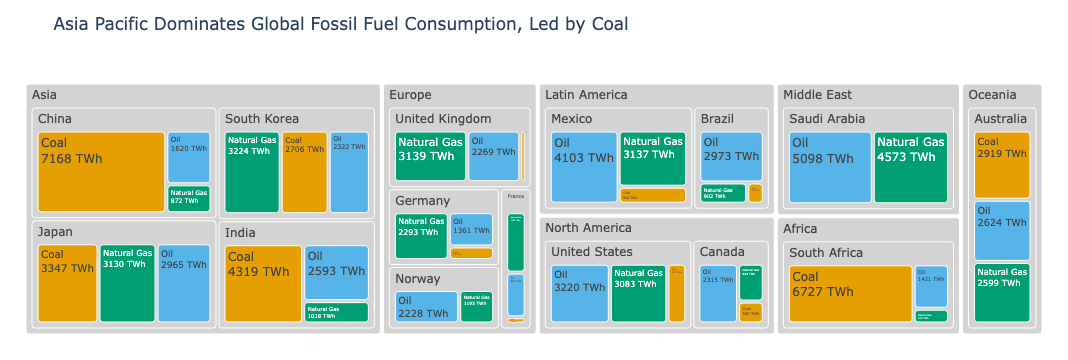

In [2]:
# Task 1

fossil_df = df.loc[df['Source_Type'] == 'Fossil'].copy()

fossil_colors = {
    'Coal': '#E69F00',      
    'Oil': '#56B4E9',       
    'Natural Gas': '#009E73' 
}
fig1 = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_colors,
    title='Asia Pacific Dominates Global Fossil Fuel Consumption, Led by Coal'
)
fig1.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:.0f} TWh',
    marker=dict(cornerradius=3)
)

fig1.update_traces(
    marker_colors=[
        '#D3D3D3' if id.count('/') < 2 else fossil_colors.get(id.split('/')[-1], '#D3D3D3')
        for id in fig1.data[0].ids
    ] if hasattr(fig1.data[0], 'ids') and fig1.data[0].ids is not None else None
)
fig1.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=12)
)
fig1.show()

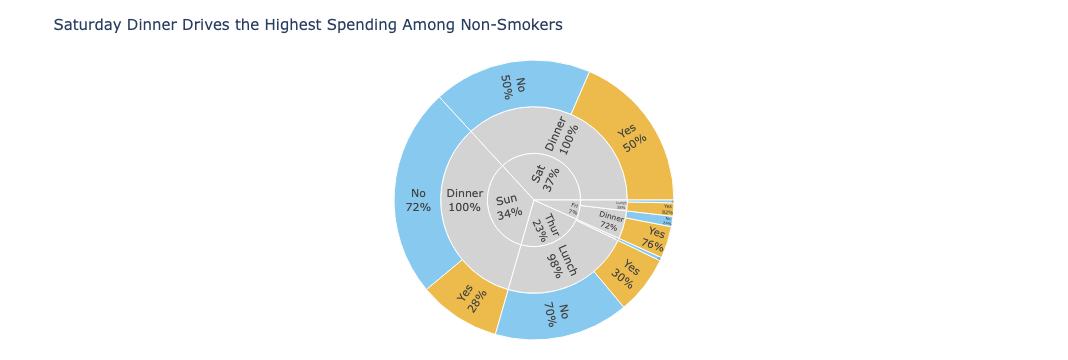

In [3]:
#Task 2

tips = px.data.tips()

tips_agg = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

smoker_colors = {
    'Yes': '#E69F00',  # Orange
    'No': '#56B4E9'    # Blue
}
fig2 = px.sunburst(
    tips_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=smoker_colors,
    title='Saturday Dinner Drives the Highest Spending Among Non-Smokers'
)
fig2.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial'
)

fig2.update_traces(
    marker=dict(
        colors=[
            smoker_colors.get(label, '#D3D3D3') 
            for label in fig2.data[0].labels
        ]
    )
)
fig2.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=11)
)
fig2.show()

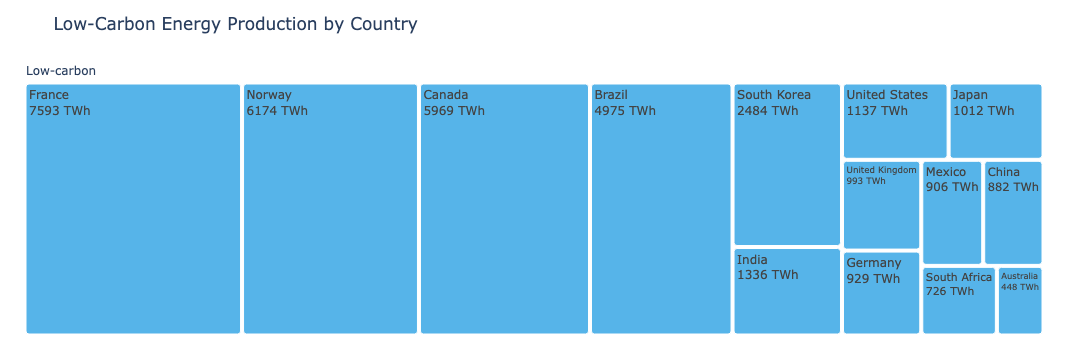

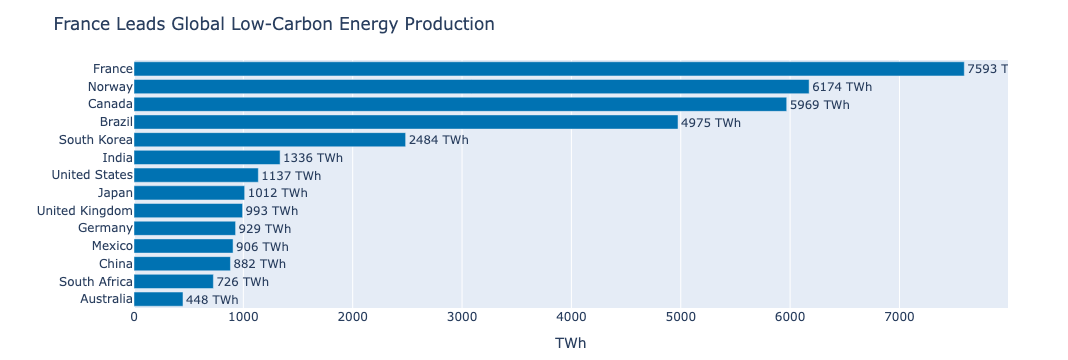

In [4]:
#Task 3

lowcarbon_df = df.loc[df['Source_Type'] == 'Low-carbon'].copy()
lowcarbon_agg = lowcarbon_df.groupby('Country')['TWh'].sum().reset_index()
lowcarbon_agg = lowcarbon_agg.sort_values('TWh', ascending=False)

lowcarbon_agg['All'] = 'Low-carbon'

fig3a = px.treemap(
    lowcarbon_agg,
    path=['All', 'Country'],
    values='TWh',
    title='Low-Carbon Energy Production by Country'
)
fig3a.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:.0f} TWh',
    marker=dict(cornerradius=3, colors=['#56B4E9'] * len(lowcarbon_agg))
)
fig3a.update_layout(
    margin=dict(t=60, l=20, r=20, b=20)
)
fig3a.show()

fig3b = px.bar(
    lowcarbon_agg.sort_values('TWh', ascending=True),
    x='TWh',
    y='Country',
    orientation='h',
    title=f'{lowcarbon_agg.iloc[0]["Country"]} Leads Global Low-Carbon Energy Production',
    text='TWh'
)
fig3b.update_traces(
    marker_color='#0072B2',
    texttemplate='%{text:.0f} TWh',
    textposition='outside'
)
fig3b.update_layout(
    xaxis_title='TWh',
    yaxis_title='',
    margin=dict(t=60, l=120, r=60, b=40),
    showlegend=False
)
fig3b.show()